In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [2]:

df = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])

# Step 2 — Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Step 3 — Create new features (Feature Engineering)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])         # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked'])  # C=0, Q=1, S=2

print(df.head())
print(df.isnull().sum())  
print(df.dtypes)          

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  FamilySize  \
0         0       3    1  22.0      1      0   7.2500         2           2   
1         1       1    0  38.0      1      0  71.2833         0           2   
2         1       3    0  26.0      0      0   7.9250         2           1   
3         1       1    0  35.0      1      0  53.1000         2           2   
4         0       3    1  35.0      0      0   8.0500         2           1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
dtype: object


In [3]:

X = df.drop(columns=['Survived'])
y = df['Survived']                  

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:", X.columns.tolist())

# Split — 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% goes to test
    random_state=42,    # fixed seed — ensures same split every run
    stratify=y          # maintain same survival ratio in both splits
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

X shape: (891, 9)
y shape: (891,)

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']

Training samples: 712
Testing samples: 179


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   # we don't fit_transform test data, it leada to data leakage

In [5]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8100558659217877


In [6]:
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:")
print(cm)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:
[[97 13]
 [21 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [7]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

print(f"{'Model':<25} {'Accuracy':<12} {'F1 Score'}")
print("-" * 50)

from sklearn.metrics import f1_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name:<25} {acc:<12.4f} {f1:.4f}")

Model                     Accuracy     F1 Score
--------------------------------------------------
Logistic Regression       0.8101       0.7385
Decision Tree             0.7821       0.7153
Random Forest             0.8045       0.7407


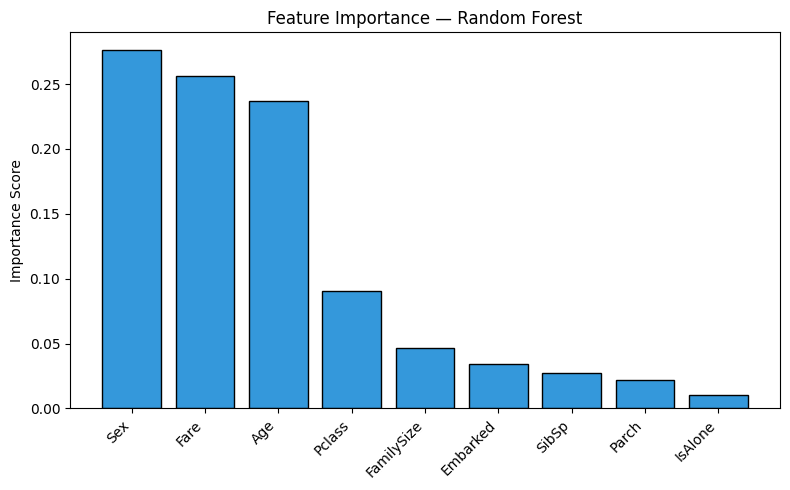

In [8]:
# Random Forest gives us feature importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature names before scaling changed them
feature_names = df.drop(columns=['Survived']).columns

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(importances)), 
       importances[indices],
       color='#3498db', edgecolor='black')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels(feature_names[indices], rotation=45, ha='right')
ax.set_title('Feature Importance — Random Forest')
ax.set_ylabel('Importance Score')
plt.tight_layout()
plt.show()